# Tugas - 8 Clustering menggunakan Fuzzy C Means

In [49]:
!pip install fuzzy-c-means
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv")
df.head()

,judul,isi,tanggal,kategori,Hasil cleansing,Hasil case_folding,tokenize,Hasil stopword
0,18 Tim yang Lolos FFWS Global Finals 2024 di B...,Jakarta - Rangkaian pertandingan di FFWS SEA 2...,"Rabu, 16 Okt 2024 19:30 WIB",Games,Jakarta Rangkaian pertandingan di FFWS SEA F...,jakarta rangkaian pertandingan di ffws sea f...,"['jakarta', 'rangkaian', 'pertandingan', 'di',...",jakarta rangkaian pertandingan ffws sea fall s...
1,Ampun Bang Jago! Zuckerberg Klaim Pemain Handa...,"Jakarta - CEO Meta Mark Zuckerberg, cukup perc...","Rabu, 16 Okt 2024 17:50 WIB",Games,Jakarta CEO Meta Mark Zuckerberg cukup percay...,jakarta ceo meta mark zuckerberg cukup percay...,"['jakarta', 'ceo', 'meta', 'mark', 'zuckerberg...",jakarta ceo meta mark zuckerberg percaya kemam...
2,"20 Game Horor Terbaik Tahun 2000an, Udah Perna...",Jakarta - Game horor selalu punya daya tarikny...,"Rabu, 16 Okt 2024 14:20 WIB",Games,Jakarta Game horor selalu punya daya tariknya...,jakarta game horor selalu punya daya tariknya...,"['jakarta', 'game', 'horor', 'selalu', 'punya'...",jakarta game horor daya tariknya penikmatnya b...
3,"Begini Cara Dapat Skin Zhou Yu HOK Gratis, Gam...",Jakarta - Ternyata cara dapat skin Zhou Yu Hon...,"Rabu, 16 Okt 2024 12:15 WIB",Games,Jakarta Ternyata cara dapat skin Zhou Yu Hono...,jakarta ternyata cara dapat skin zhou yu hono...,"['jakarta', 'ternyata', 'cara', 'dapat', 'skin...",jakarta skin zhou yu honor of kings hok gratis...
4,"Gagal Juara FFWS SEA 2024 Fall, Wakil RI: Kita...","Jakarta - Tampil di depan ribuan pendukungnya,...","Selasa, 15 Okt 2024 17:36 WIB",Games,Jakarta Tampil di depan ribuan pendukungnya t...,jakarta tampil di depan ribuan pendukungnya t...,"['jakarta', 'tampil', 'di', 'depan', 'ribuan',...",jakarta tampil ribuan pendukungnya wakil indon...


In [52]:
texts = df['Hasil stopword']

In [53]:
# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [54]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)
X_tfidf.shape

(100, 4290)

In [55]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

# Pastikan X_scaled sudah terdefinisi sebelumnya

# Inisialisasi variabel untuk menyimpan hasil
best_silhouette = -1
best_ari = -1
best_nmi = -1
best_n_components = 0
results = {}

# Asumsikan y_true adalah label asli dari dataset Anda
y_true = df['kategori']  # Ganti 'kategori' dengan nama kolom label asli

for n in range(2, 100):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(X_scaled)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, error=0.001, random_state=42)
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score, ARI, dan NMI
    silhouette = silhouette_score(data_reduced, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    results[n] = {
        'silhouette': silhouette,
        'ari': ari,
        'nmi': nmi
    }

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette={silhouette}, ARI={ari}, NMI={nmi}")

    # Perbarui nilai terbaik
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_components = n
    if ari > best_ari:
        best_ari = ari
    if nmi > best_nmi:
        best_nmi = nmi

Iterasi dengan n_components=2: Silhouette=0.9493419040102825, ARI=0.0, NMI=0.018639764244343528
Iterasi dengan n_components=3: Silhouette=0.8928573458012268, ARI=0.008096346523631212, NMI=0.08068918390116896
Iterasi dengan n_components=4: Silhouette=0.8481067296897272, ARI=0.02269374787246114, NMI=0.1212746751286823
Iterasi dengan n_components=5: Silhouette=0.8583790784305891, ARI=0.01701445012943135, NMI=0.10806496399729751
Iterasi dengan n_components=6: Silhouette=0.8373112952947324, ARI=0.02918749315918129, NMI=0.13426149725450204
Iterasi dengan n_components=7: Silhouette=0.8488396462055162, ARI=0.02269374787246114, NMI=0.1212746751286823
Iterasi dengan n_components=8: Silhouette=0.8326034836545628, ARI=0.02918749315918129, NMI=0.13426149725450204
Iterasi dengan n_components=9: Silhouette=0.524225663884839, ARI=0.2646838453269049, NMI=0.35836787134097936
Iterasi dengan n_components=10: Silhouette=0.37258741263175665, ARI=0.4852686308492201, NMI=0.5102432713148242
Iterasi dengan n_co

In [56]:
# Menyimpan hasil terbaik untuk setiap metrik
best_silhouette_n_components = max(results, key=lambda x: results[x]['silhouette'])
best_ari_n_components = max(results, key=lambda x: results[x]['ari'])
best_nmi_n_components = max(results, key=lambda x: results[x]['nmi'])

# Menampilkan hasil terbaik
print(f"\nBest Silhouette Score is achieved by n_components={best_silhouette_n_components} with score: {results[best_silhouette_n_components]['silhouette']}")
print(f"Best ARI is achieved by n_components={best_ari_n_components} with score: {results[best_ari_n_components]['ari']}")
print(f"Best NMI is achieved by n_components={best_nmi_n_components} with score: {results[best_nmi_n_components]['nmi']}")



Best Silhouette Score is achieved by n_components=2 with score: 0.9493419040102825
Best ARI is achieved by n_components=22 with score: 0.8824165642894751
Best NMI is achieved by n_components=22 with score: 0.8347636587075117


In [57]:
# Mengurutkan hasil berdasarkan silhouette score (dari tertinggi ke terendah)
sorted_results = sorted(results.items(), key=lambda x: x[1]['silhouette'], reverse=True)

# Menampilkan hasil akhir
print(f"\nBest n_components: {best_n_components} with silhouette score: {best_silhouette}")
print("\nAll results (sorted by silhouette score):")
for n, score in sorted_results:
    print(f"n_components={n}: Silhouette Score={score}")


Best n_components: 2 with silhouette score: 0.9493419040102825

All results (sorted by silhouette score):
n_components=2: Silhouette Score={'silhouette': 0.9493419040102825, 'ari': 0.0, 'nmi': 0.018639764244343528}
n_components=3: Silhouette Score={'silhouette': 0.8928573458012268, 'ari': 0.008096346523631212, 'nmi': 0.08068918390116896}
n_components=5: Silhouette Score={'silhouette': 0.8583790784305891, 'ari': 0.01701445012943135, 'nmi': 0.10806496399729751}
n_components=7: Silhouette Score={'silhouette': 0.8488396462055162, 'ari': 0.02269374787246114, 'nmi': 0.1212746751286823}
n_components=4: Silhouette Score={'silhouette': 0.8481067296897272, 'ari': 0.02269374787246114, 'nmi': 0.1212746751286823}
n_components=6: Silhouette Score={'silhouette': 0.8373112952947324, 'ari': 0.02918749315918129, 'nmi': 0.13426149725450204}
n_components=8: Silhouette Score={'silhouette': 0.8326034836545628, 'ari': 0.02918749315918129, 'nmi': 0.13426149725450204}
n_components=9: Silhouette Score={'silhou

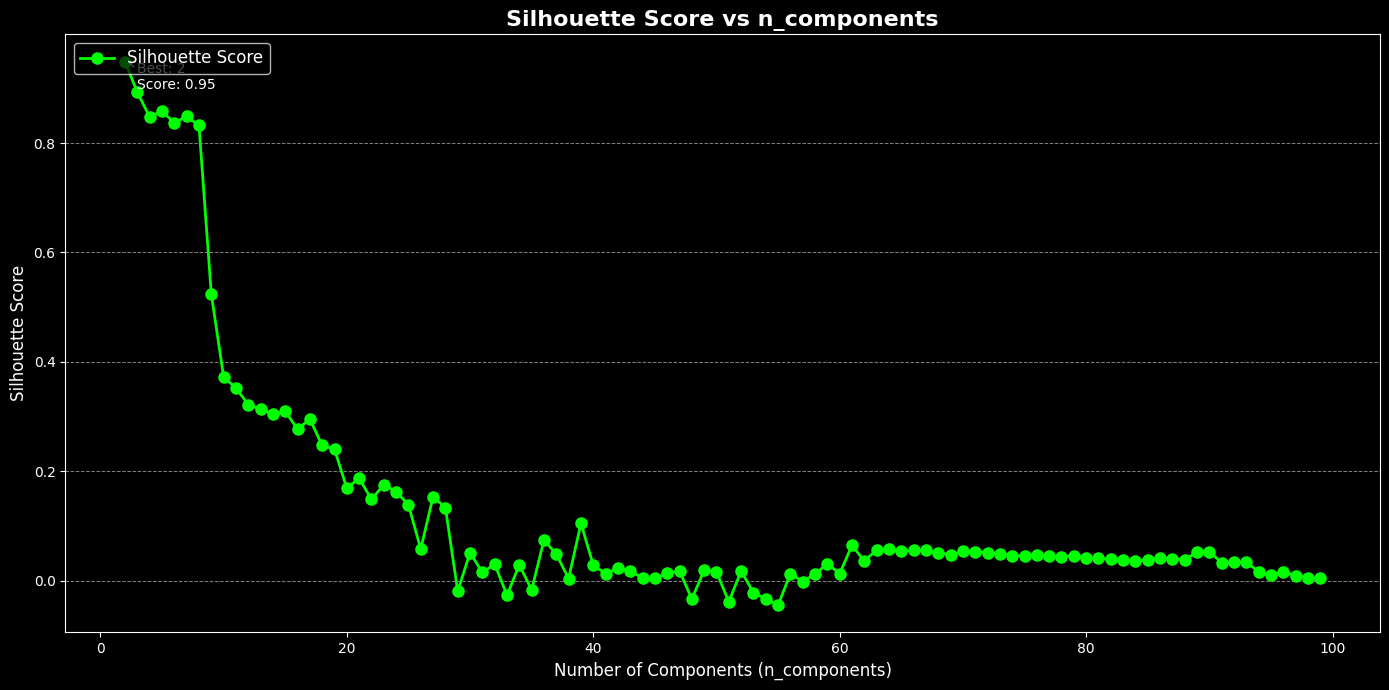

In [58]:
import matplotlib.pyplot as plt

# Data untuk plotting
n_components = list(results.keys())
silhouette_scores = [metrics['silhouette'] for metrics in results.values()]

# Ganti dengan style bawaan yang mirip
plt.style.use("dark_background")

# Membuat figure dengan nuansa grafik trading
plt.figure(figsize=(14, 7))

# Plot garis dengan marker
plt.plot(n_components, silhouette_scores, label="Silhouette Score", color="lime", linewidth=2, marker="o", markersize=8)

# Menambahkan grid horizontal
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

# Menambahkan judul dan label
plt.title("Silhouette Score vs n_components", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Number of Components (n_components)", fontsize=12, color="white")
plt.ylabel("Silhouette Score", fontsize=12, color="white")

# Menambahkan anotasi untuk nilai maksimum
max_score = max(silhouette_scores)
best_n = n_components[silhouette_scores.index(max_score)]
plt.annotate(f"Best: {best_n}\nScore: {max_score:.2f}",
             xy=(best_n, max_score), xytext=(best_n + 1, max_score - 0.05),
             arrowprops=dict(facecolor='red', arrowstyle="->"),
             fontsize=10, color="white")

# Menambahkan legenda
plt.legend(fontsize=12, loc="upper left", facecolor="black", edgecolor="white", framealpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

# Clustering

Silhouette Score: 0.1482
Jumlah data pada setiap cluster:
Cluster
1    53
0    47
Name: count, dtype: int64


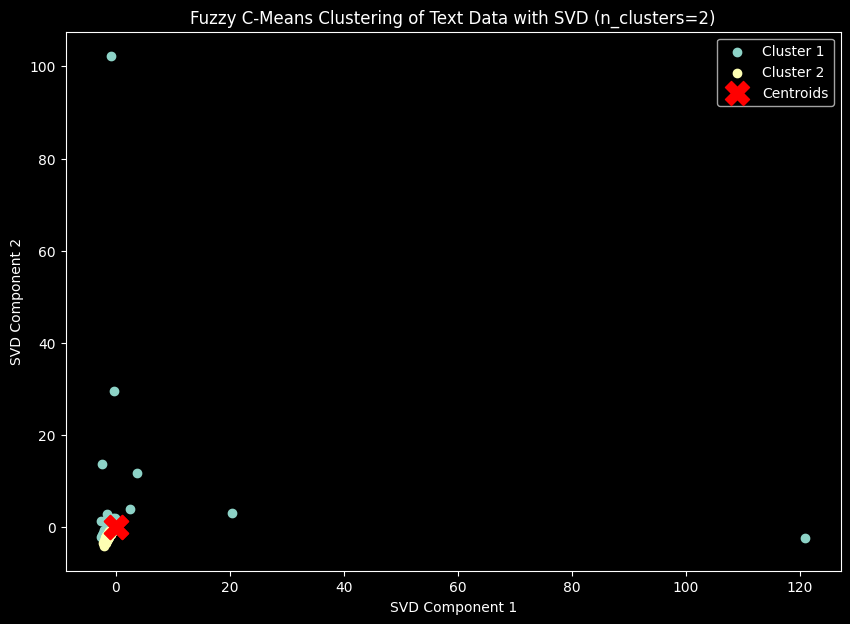

In [59]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Untuk manipulasi DataFrame

df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv')
data = df['Hasil stopword']
random_seed = 42  # Tetapkan seed untuk konsistensi

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
tfidf = tfidf_matrix.toarray()

#Step 3 Normalisasi Hasil TF-IDF
scaler = StandardScaler()
data_normalisasi = scaler.fit_transform(tfidf)

# Step 4 : Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=22 , random_state=random_seed)
data_cluster = svd.fit_transform(data_normalisasi)



# Fuzzy C-Means Clustering
n_clusters = 2  # Ganti sesuai kebutuhan
fcm = FCM(n_clusters=n_clusters, m=2.0, max_iter=1000, epsilon=0.001, random_state=random_seed)
fcm.fit(data_cluster)

# Mendapatkan hasil clustering
membership = fcm.u
cluster_labels = np.argmax(membership, axis=1)  # Menentukan cluster untuk setiap data
# Tambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
# Tampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
# Tambahkan setelah cluster_labels dihasilkan
silhouette_avg = silhouette_score(data_cluster, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Cetak hasil jumlah data per cluster
print("Jumlah data pada setiap cluster:")
print(cluster_counts)


# Visualisasi hasil clustering
plt.figure(figsize=(10, 7))

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    plt.scatter(data_cluster[cluster_labels == i, 0],
                data_cluster[cluster_labels == i, 1], label=f'Cluster {i+1}')

# Plot centroid
cluster_centers = fcm.centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [60]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
df

,judul,isi,tanggal,kategori,Hasil cleansing,Hasil case_folding,tokenize,Hasil stopword,Cluster
0,18 Tim yang Lolos FFWS Global Finals 2024 di B...,Jakarta - Rangkaian pertandingan di FFWS SEA 2...,"Rabu, 16 Okt 2024 19:30 WIB",Games,Jakarta Rangkaian pertandingan di FFWS SEA F...,jakarta rangkaian pertandingan di ffws sea f...,"['jakarta', 'rangkaian', 'pertandingan', 'di',...",jakarta rangkaian pertandingan ffws sea fall s...,0
1,Ampun Bang Jago! Zuckerberg Klaim Pemain Handa...,"Jakarta - CEO Meta Mark Zuckerberg, cukup perc...","Rabu, 16 Okt 2024 17:50 WIB",Games,Jakarta CEO Meta Mark Zuckerberg cukup percay...,jakarta ceo meta mark zuckerberg cukup percay...,"['jakarta', 'ceo', 'meta', 'mark', 'zuckerberg...",jakarta ceo meta mark zuckerberg percaya kemam...,1
2,"20 Game Horor Terbaik Tahun 2000an, Udah Perna...",Jakarta - Game horor selalu punya daya tarikny...,"Rabu, 16 Okt 2024 14:20 WIB",Games,Jakarta Game horor selalu punya daya tariknya...,jakarta game horor selalu punya daya tariknya...,"['jakarta', 'game', 'horor', 'selalu', 'punya'...",jakarta game horor daya tariknya penikmatnya b...,0
3,"Begini Cara Dapat Skin Zhou Yu HOK Gratis, Gam...",Jakarta - Ternyata cara dapat skin Zhou Yu Hon...,"Rabu, 16 Okt 2024 12:15 WIB",Games,Jakarta Ternyata cara dapat skin Zhou Yu Hono...,jakarta ternyata cara dapat skin zhou yu hono...,"['jakarta', 'ternyata', 'cara', 'dapat', 'skin...",jakarta skin zhou yu honor of kings hok gratis...,0
4,"Gagal Juara FFWS SEA 2024 Fall, Wakil RI: Kita...","Jakarta - Tampil di depan ribuan pendukungnya,...","Selasa, 15 Okt 2024 17:36 WIB",Games,Jakarta Tampil di depan ribuan pendukungnya t...,jakarta tampil di depan ribuan pendukungnya t...,"['jakarta', 'tampil', 'di', 'depan', 'ribuan',...",jakarta tampil ribuan pendukungnya wakil indon...,0
...,...,...,...,...,...,...,...,...,...
95,Rating Pemain China Vs Indonesia: Thom Haye Te...,Jakarta - China vs Indonesia tuntas 2-1 di lan...,"Rabu, 16 Okt 2024 12:00 WIB",Sepak Bola,Jakarta China vs Indonesia tuntas di lanjuta...,jakarta china vs indonesia tuntas di lanjuta...,"['jakarta', 'china', 'vs', 'indonesia', 'tunta...",jakarta china vs indonesia tuntas lanjutan kua...,1
96,China Vs Indonesia: Coret Eliano Reijnders Blu...,Qingdao - Keputusan mencoret Eliano Reijnders ...,"Rabu, 16 Okt 2024 11:40 WIB",Sepak Bola,Qingdao Keputusan mencoret Eliano Reijnders s...,qingdao keputusan mencoret eliano reijnders s...,"['qingdao', 'keputusan', 'mencoret', 'eliano',...",qingdao keputusan mencoret eliano reijnders me...,1
97,Dumfries Akui Performanya Lebih Baik di Timnas...,"Jakarta - Denzel Dumfries mengakui, performany...","Rabu, 16 Okt 2024 11:20 WIB",Sepak Bola,Jakarta Denzel Dumfries mengakui performanya ...,jakarta denzel dumfries mengakui performanya ...,"['jakarta', 'denzel', 'dumfries', 'mengakui', ...",jakarta denzel dumfries mengakui performanya t...,1
98,Hasil Lengkap-Klasemen Kualifikasi Piala Dunia...,Jakarta - Matchday 4 di babak ketiga kualifika...,"Rabu, 16 Okt 2024 11:00 WIB",Sepak Bola,Jakarta Matchday di babak ketiga kualifikasi...,jakarta matchday di babak ketiga kualifikasi...,"['jakarta', 'matchday', 'di', 'babak', 'ketiga...",jakarta matchday babak ketiga kualifikasi pial...,1


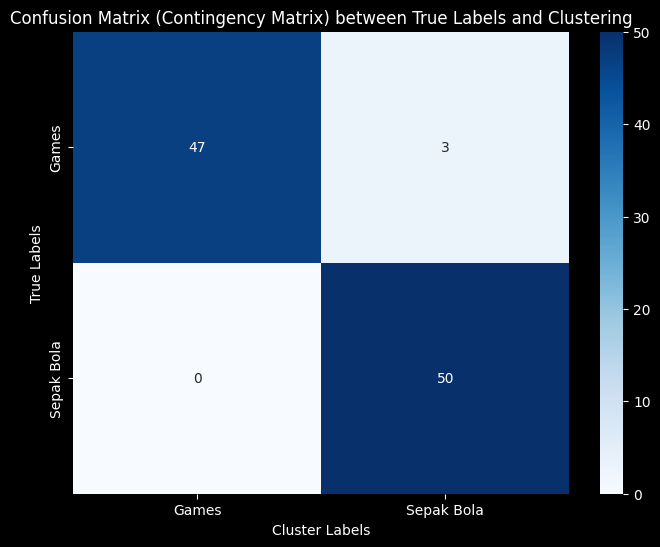

Confusion Matrix (Contingency Matrix):
[[47  3]
 [ 0 50]]


In [61]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil kolom kategori dari dataframe sebagai label asli (true labels)
true_labels = df['kategori']  # Ganti 'kategori' dengan nama kolom kategori di DataFrame Anda

# Gunakan LabelEncoder untuk mengubah kategori menjadi angka
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(true_labels)

# Hitung confusion matrix antara true labels dan hasil clustering
conf_matrix = confusion_matrix(true_labels_encoded, cluster_labels)

# Tampilkan confusion matrix menggunakan heatmap untuk visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Contingency Matrix) between True Labels and Clustering')
plt.xlabel('Cluster Labels')
plt.ylabel('True Labels')
plt.show()

# Cetak confusion matrix secara numerik
print("Confusion Matrix (Contingency Matrix):")
print(conf_matrix)

In [62]:
from sklearn.metrics import silhouette_score
import numpy as np

# Mengonversi keanggotaan fuzzy menjadi label cluster dengan memilih cluster dengan membership tertinggi
fuzzy_labels = np.argmax(membership, axis=1)

# Menghitung Silhouette Score
silhouette_avg = silhouette_score(data_cluster, fuzzy_labels)

# Menampilkan Silhouette Score
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.1482


In [63]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
import joblib
import pandas as pd

# Membaca data
df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv')
data = df['Hasil stopword'].astype(str)  # Pastikan data berupa string

# Fungsi untuk menerapkan FCM dalam pipeline
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,         # Jumlah cluster yang diinginkan
        m=2.0,                # Fuzziness coefficient
        max_iter=1000,        # Maksimal iterasi
        epsilon=0.001,        # Toleransi konvergensi
        random_state=42       # Menetapkan seed untuk random state
    )
    fcm.fit(X)
    return fcm

# Fungsi pembungkus untuk FCM (untuk FunctionTransformer)
def fit_fcm_wrapper(X):
    return fit_fcm(X)

# Membuat pipeline dengan FCM dan parameter yang diberikan
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # TF-IDF untuk teks
    ('scaler', StandardScaler(with_mean=False)),  # Normalisasi data
    ('svd', TruncatedSVD(n_components=22)),  # Reduksi Dimensi
    ('fcm', FunctionTransformer(func=fit_fcm_wrapper))  # Menggunakan FCM melalui FunctionTransformer
])

# Fit pipeline pada data pelatihan
pipeline.fit(data)

# Simpan pipeline yang telah dilatih
joblib.dump(pipeline, 'svd_tfidf_scaler_fcm_pipeline.pkl')

['svd_tfidf_scaler_fcm_pipeline.pkl']

In [65]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
import numpy as np
import pandas as pd

# 1. Memuat pipeline yang sudah dilatih sebelumnya
pipeline = joblib.load('svd_tfidf_scaler_fcm_pipeline.pkl')

# 2. Melakukan FCM pada data pelatihan (sudah dilabeli Games dan Sepakbola)
# Misalnya, kita memiliki data pelatihan yang dilabeli sebagai berikut:
df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv')  # Ganti dengan path data pelatihan Anda
data_pelatihan = df['Hasil stopword']  # Kolom yang berisi teks

# Transformasi data pelatihan menggunakan pipeline
X_train_transformed = pipeline[:-1].transform(data_pelatihan)  # Tanpa FCM, hanya TF-IDF, Scaling, dan SVD
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

# 3. Melakukan clustering FCM pada data pelatihan
fcm_model = FCM(n_clusters=2, m=2.0, max_iter=1000, epsilon=0.001, random_state=42)
fcm_model.fit(X_train_transformed)

# 4. Menyelaraskan cluster dengan label yang diketahui (Games = 0, Sepakbola = 1)
# Misalnya, jika label pada data pelatihan adalah:
labels_train = df['kategori']  # Kolom label, yang bisa berisi 0 (Games) dan 1 (Sepakbola)

# Menyelaraskan cluster dengan label
cluster_labels = fcm_model.predict(X_train_transformed)
# Misalkan cluster 0 harus menjadi Games dan cluster 1 harus menjadi Sepakbola
cluster_to_label = {0: 'Games', 1: 'Sepakbola'}

# Menyelaraskan prediksi cluster dengan label
predicted_labels = [cluster_to_label[cluster] for cluster in cluster_labels]

# 5. Memuat data baru untuk prediksi
teks_baru = """
Jakarta - Dalam ranking FIFA terbaru, Jepang masih perkasa sebagai tim Asia dengan peringkat tertinggi. Pasukan Samurai Biru ada di peringkat ke-16!
FIFA merilis ranking FIFA terbaru per September 2024 pada Jumat (19/9). Untuk di level Asia, Jepang masih menempati peringkat teratas.
Timnas Jepang duduk di peringkat ke-16 ranking FIFA terbaru dengan 1639.6 poin. Wataru Endo dkk naik dua peringkat.
epang mampu sapu bersih dua kemenangan di dua laga awal ronde ketiga Kualifikasi Piala Dunia 2026 Zona Asia. Jepang pesta gol atas China 7-0 dan cukur Bahrain 5-0.
Jepang pun menjadi satu-satunya tim dengan poin sempurna sejauh ini di Grup C dengan enam poin. Mereka disusul Arab Saudi (empat poin), Bahrain (tiga poin), dan Indonesia (dua poin)."""

# Transformasi data baru menggunakan pipeline
X_new_transformed = pipeline[:-1].transform([teks_baru])
if hasattr(X_new_transformed, 'toarray'):
    X_new_transformed = X_new_transformed.toarray()

# 6. Prediksi cluster untuk data baru
cluster_new = fcm_model.predict(X_new_transformed)

# Menyelaraskan prediksi cluster dengan label
predicted_label_new = cluster_to_label[cluster_new[0]]

# 7. Menampilkan hasil
print(f"Teks baru ini diprediksi ke dalam cluster: {predicted_label_new}")


Teks baru ini diprediksi ke dalam cluster: Sepakbola
